JUAN SEBASTIÁN GRACIA LOZANO

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
df = pd.read_csv('student-por.csv', sep=';')

Saving student-por.csv to student-por (2).csv


In [ ]:
df.shape

(649, 33)

El conjunto de datos contiene un total de 649 registros (estudiantes) y 33 variables (columnas). Esto brinda un volumen de datos suficiente para un análisis estadístico robusto, ofreciendo una visión amplia de factores demográficos, familiares y académicos por cada alumno.



¿Existen registros duplicados dentro de las 649 filas cargadas?

¿Se identifican valores nulos o incompletos en alguna de las 33 columnas?

¿Todas las 33 variables aportan valor al análisis o hay columnas redundantes que puedan descartarse en la etapa de limpieza?

In [ ]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


Conclusión: Solo hay dos tipos de datos: int64 (conteos y escalas de 1 a 5) y object (categorías de texto y banderas 'yes'/'no'). No existen variables tipo float.


¿Conviene convertir las variables binarias ('yes'/'no') a números (1/0)?

¿Alguna columna object esconde valores numéricos guardados como texto?

In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


Muestra las primeras 5 filas del dataset. Las observaciones iniciales corresponden únicamente a mujeres (F), del colegio GP y zona urbana (U), con edades entre 15 y 18 años y variabilidad en la ocupación de los padres, hábitos y ausencias.


¿El género femenino y el colegio GP están sobre-representados en todo el dataset o solo coincide en los primeros registros?

¿Los valores de ausencias (absences) y hábitos presentan valores fuera de rango o sesgos marcados en el resto del dataset?


DUPLICADOS PARTE II.1

In [ ]:
df[df.duplicated(keep=False)]

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3


No existen filas idénticas en el conjunto de datos; los 649 registros son únicos al evaluar la totalidad de las 33 columnas.

¿Podría haber registros repetidos del mismo estudiante si omitimos algunas columnas secundarias (duplicados parciales)?

¿Es necesario definir una clave primaria compuesta (por ejemplo: colegio + sexo + edad) para confirmar la unicidad de cada estudiante?

PARTE II.2

In [ ]:
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    print(df[col].value_counts())

school
GP    423
MS    226
Name: count, dtype: int64
sex
F    383
M    266
Name: count, dtype: int64
address
U    452
R    197
Name: count, dtype: int64
famsize
GT3    457
LE3    192
Name: count, dtype: int64
Pstatus
T    569
A     80
Name: count, dtype: int64
Mjob
other       258
services    136
at_home     135
teacher      72
health       48
Name: count, dtype: int64
Fjob
other       367
services    181
at_home      42
teacher      36
health       23
Name: count, dtype: int64
reason
course        285
home          149
reputation    143
other          72
Name: count, dtype: int64
guardian
mother    455
father    153
other      41
Name: count, dtype: int64
schoolsup
no     581
yes     68
Name: count, dtype: int64
famsup
yes    398
no     251
Name: count, dtype: int64
paid
no     610
yes     39
Name: count, dtype: int64
activities
no     334
yes    315
Name: count, dtype: int64
nursery
yes    521
no     128
Name: count, dtype: int64
higher
yes    580
no      69
Name: count, dtype: int64

Existe una clara preferencia o sesgo en el perfil del estudiante.

Predominan los estudiantes de GP (65%), zona urbana (70%), mujeres (59%), familias con >3 integrantes (70%) y padres convivientes (88%).

Casi todos tienen tutoría materna (70%) y apoyo familiar (famsup: 61%), pero casi ninguno recibe soporte escolar extra (schoolsup: 10%) o clases pagadas (paid: 6%).


¿Afectará el fuerte desbalance en schoolsup y paid la predicción del rendimiento?

¿Influye el tipo de colegio o zona en el acceso al apoyo educativo?

In [ ]:
print("No aplica formato de fecha para este dataset")

No aplica formato de fecha para este dataset


II.4 VALORES NULOS

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df.isna().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


No hay datos faltantes (nulos) en ninguna de las variables analizadas. La base de datos está completamente diligenciada en estas columnas.


¿Existen valores nulos implícitos o codificados con caracteres especiales que Python no haya detectado como NaN?

¿Se confirma que no se requiere aplicar ningún algoritmo de imputación de datos?

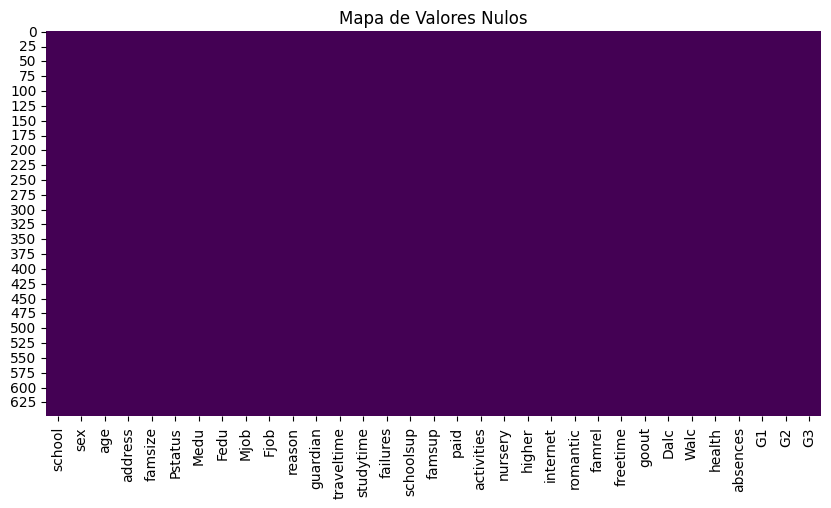

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title('Mapa de Valores Nulos')
plt.show()

El mapa presenta un bloque totalmente uniforme sin líneas ni franjas de distinto color, confirmando visualmente la ausencia total de valores nulos (NaN) en las 33 columnas de la base de datos.


¿Hay caracteres especiales (como cadenas vacías o  "?") que puedan ocultar nulos sin ser detectados por isna()?

¿Se confirma que el dataset está 100% completo para pasar directamente a la etapa de análisis exploratorio y modelado?

II.5 IMPOSIBLES VS ATÍPICOS



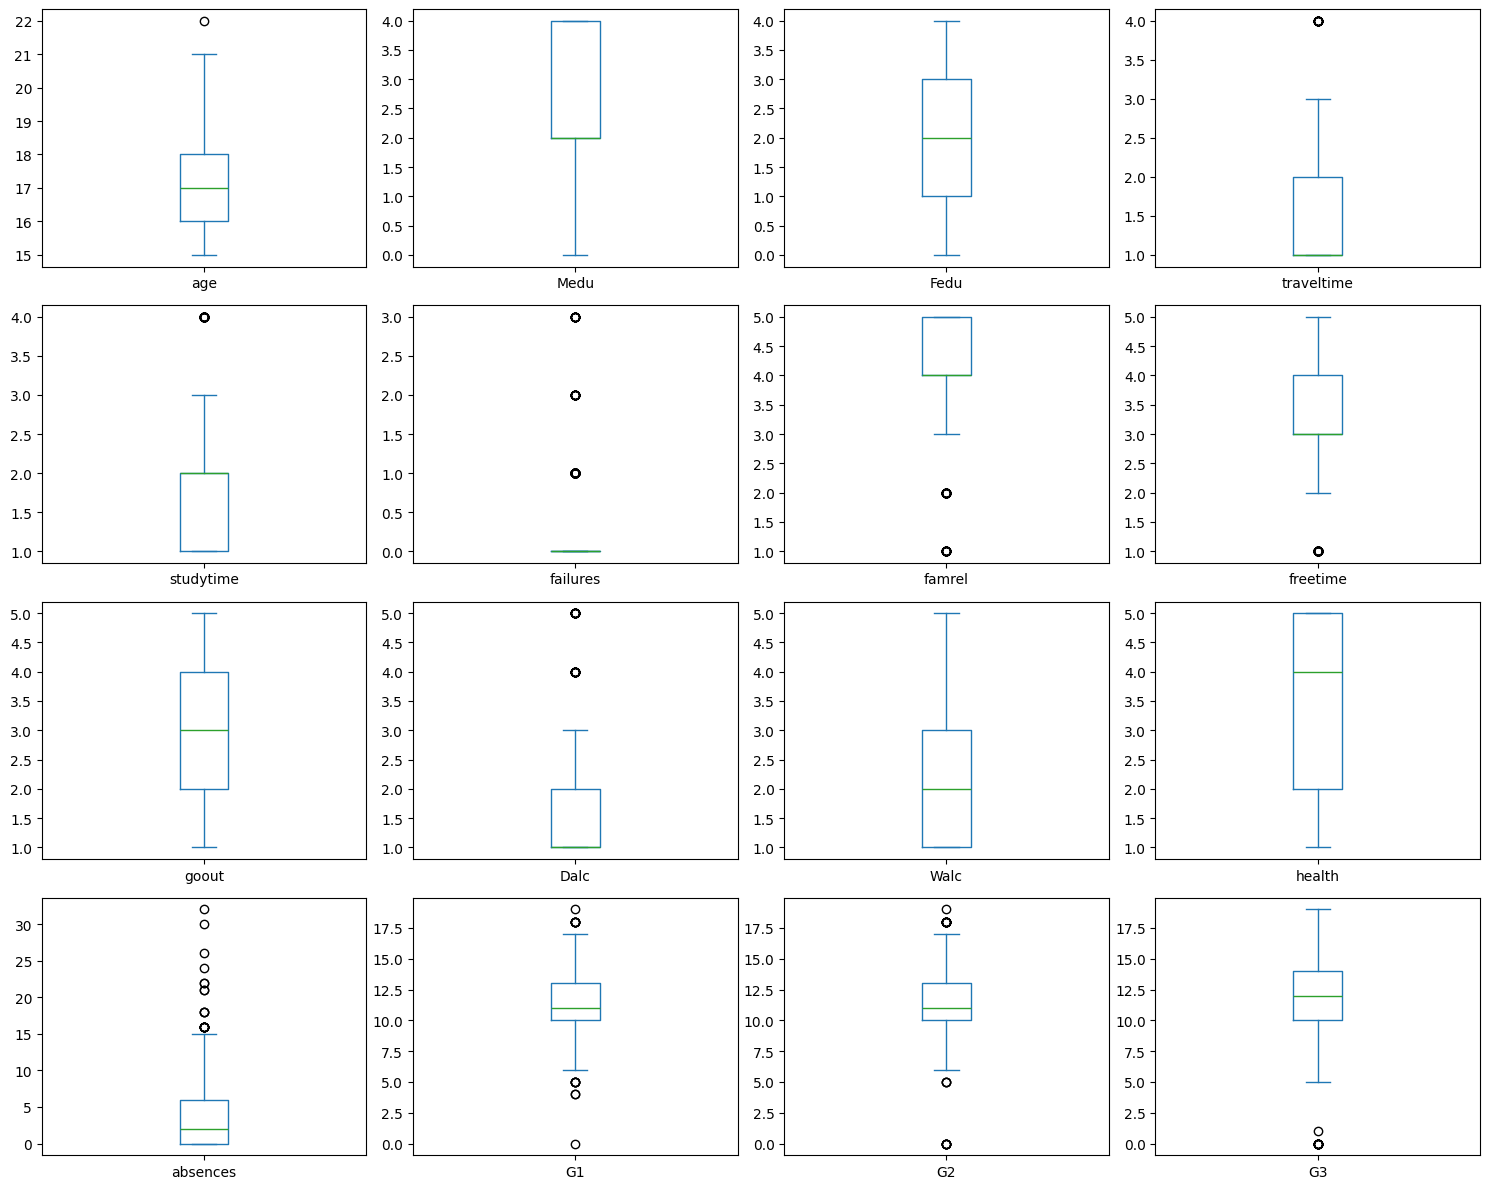

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].plot(kind='box', subplots=True, layout=(4, 4), figsize=(15, 12))
plt.tight_layout()
plt.show()

La mayoría de las escalas ordinales (1 a 5) presentan distribuciones bien centradas. Sin embargo, destacan outliers claros en varias variables: edades avanzadas (age > 20), tiempos altos de viaje/estudio (traveltime, studytime), consumo elevado de alcohol en semana (Dalc), baja calidad en relaciones familiares (famrel), estudiantes con materias reprobadas (failures) y ausencias extremas (absences).


¿Los valores atípicos (como edades > 20 o ausencias elevadas) representan casos reales válidos o errores de registro que deban corregirse/limitarse?

¿Se requiere aplicar alguna técnica de transformación de datos o truncamiento (clipping) para evitar que los outliers distorsionen los modelos?

II.7 REPORTE DE IMPACTO

In [ ]:
filas_iniciales = len(df)
filas_finales = len(df)
porcentaje_afectado = ((filas_iniciales - filas_finales) / filas_iniciales) * 100
print(f"Porcentaje de filas afectadas por limpieza: {porcentaje_afectado}%")

Porcentaje de filas afectadas por limpieza: 0.0%


Se conservó el 100% del dataset original (649 registros), ya que el proceso de limpieza tuvo un impacto del 0.0% en la eliminación o pérdida de registros.

¿Significa esto que no se requería filtrado por nulos/duplicados, o que los outliers detectados previamente se conservaron intencionalmente?

¿Se aplicó algún tipo de limpieza a nivel de columnas o valores sin alterar la cantidad total de filas?

IV LAS CUATRO PREGUNTAS DEL EDA

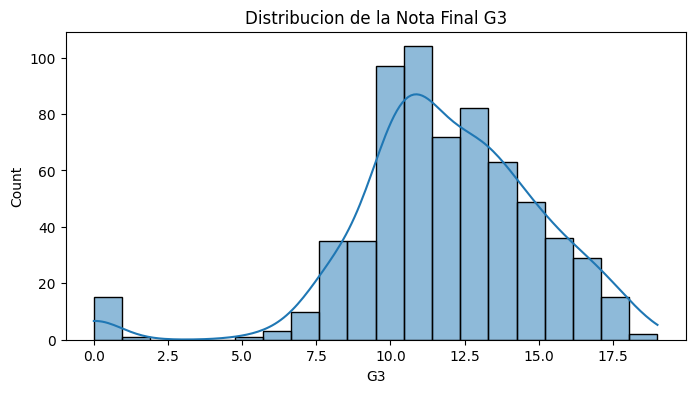

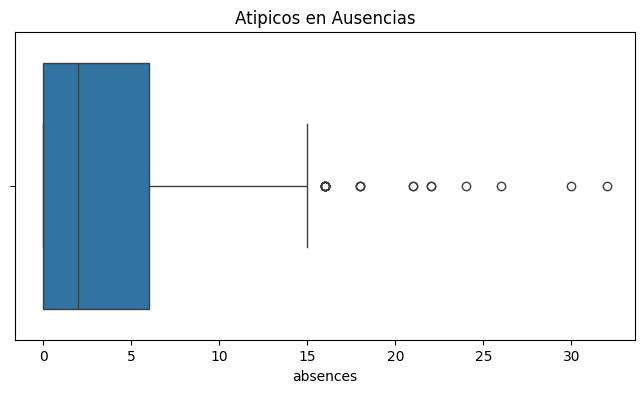

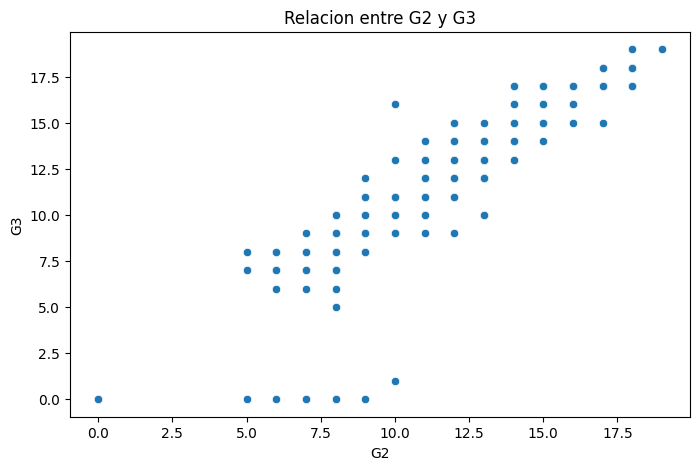

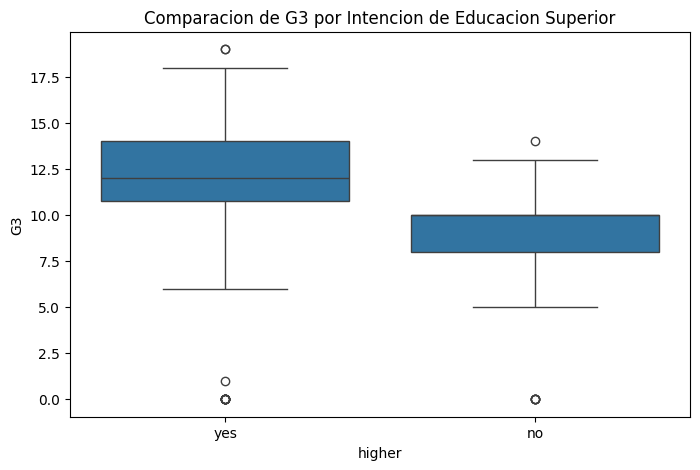

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['G3'], kde=True, bins=20)
plt.title('Distribucion de la Nota Final G3')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['absences'])
plt.title('Atipicos en Ausencias')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='G2', y='G3', data=df)
plt.title('Relacion entre G2 y G3')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='higher', y='G3', data=df)
plt.title('Comparacion de G3 por Intencion de Educacion Superior')
plt.show()

El desempeño académico final (G3) está fuertemente vinculado con la nota previa (G2) y la motivación por cursar educación superior; sin embargo, existen valores atípicos críticos que deben tratarse adecuadamente para no distorsionar los análisis ni los modelos predictivos.


¿Por qué algunos estudiantes con notas aprobatorias en G2 obtuvieron una calificación final de 0 en G3?

¿Las ausencias elevadas Son la causa principal de la reprobación o desproporción en las notas?

¿Es necesario filtrar los ceros o aplicar transformaciones a los outliers antes de entrenar un modelo predictivo?

¿Tiene mayor peso predictivo sobre la nota final la aspiración académica (higher) o el rendimiento previo del alumno (G2)?

V UN GRAFICO COMUNICATIVO

/tmp/ipykernel_1736/2610263773.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='higher', y='G3', data=df, ci=None, palette=['#e74c3c', '#2ecc71'])
/tmp/ipykernel_1736/2610263773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='higher', y='G3', data=df, ci=None, palette=['#e74c3c', '#2ecc71'])


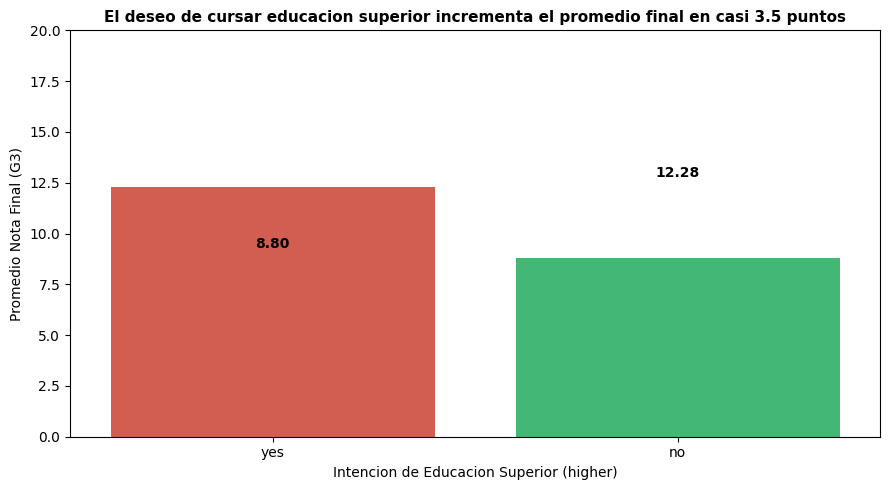

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(x='higher', y='G3', data=df, ci=None, palette=['#e74c3c', '#2ecc71'])
plt.title('El deseo de cursar educacion superior incrementa el promedio final en casi 3.5 puntos', fontsize=11, fontweight='bold')
plt.xlabel('Intencion de Educacion Superior (higher)', fontsize=10)
plt.ylabel('Promedio Nota Final (G3)', fontsize=10)
plt.ylim(0, 20)
for index, row in df.groupby('higher')['G3'].mean().reset_index().iterrows():
    plt.text(index, row['G3'] + 0.5, f"{row['G3']:.2f}", color='black', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Los estudiantes que aspiran a la educación superior (yes) obtienen un promedio de 12.28 frente a un 8.80 de quienes no lo contemplan (no), reflejando una diferencia de 3.48 puntos.

¿A qué se debe que las etiquetas con los valores numéricos hayan quedado cruzadas en la visualización?

¿Esta brecha de 3.5 puntos está impulsada principalmente por la motivación individual o por factores como el nivel socioeconómico?

### Lo que ya saben hacer

- [x] Puedo explicar la diferencia entre un valor imposible y un valor atípico con un ejemplo propio, no solo con el de las bicicletas.
- [x] Sé nombrar las tres estrategias frente a un dato faltante y cuándo usar cada una.
- [x] Entiendo por qué la estrategia de limpieza puede cambiar según el tamaño del dataset.
- [x] Puedo distinguir, en cualquier gráfico que me muestren, si fue hecho para explorar o para comunicar.
- [x] Sé nombrar las cuatro preguntas del análisis exploratorio sin mirar este cuaderno.
- [x] Mi gráfico final tiene un título que afirma una conclusión, no que nombra una variable.
- [x] Puedo decir cuántos de mis registros quedaron afectados por mis propias decisiones de limpieza.

BIBLIOGRAFÍA

Student Performance - UCI Machine Learning Repository. (s. f.). https://uci-ics-mlr-prod.aws.uci.edu/dataset/320/student%2Bperformance